In [7]:
## Import Packages

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
# Load data
data = pd.read_csv("bitcoin_data/raw/btc_3h.csv")

In [9]:
data.head()

,datetime,open,high,low,close,volume
0,2020-01-01 00:00:00,7195.24,7244.87,7175.46,7242.85,2050.024313
1,2020-01-01 03:00:00,7242.66,7245.00,7215.03,7224.21,1596.208041
2,2020-01-01 06:00:00,7224.24,7236.27,7180.00,7200.64,2164.357851
3,2020-01-01 09:00:00,7200.29,7237.73,7185.20,7197.20,2251.108387
4,2020-01-01 12:00:00,7197.20,7234.97,7196.15,7221.43,2098.648667


In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 18661 entries, 0 to 18660
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  18661 non-null  str    
 1   open      18661 non-null  float64
 2   high      18661 non-null  float64
 3   low       18661 non-null  float64
 4   close     18661 non-null  float64
 5   volume    18661 non-null  float64
dtypes: float64(5), str(1)
memory usage: 874.9 KB


In [11]:
df = data.copy()

### Data Engineering

In [13]:
df['close_log_return'] = np.log(df['close'] / df['close'].shift(1))

In [14]:
df['volume_log_return'] = np.log(df['volume'] / df['volume'].shift(1))

In [15]:
df['open_log_return'] = np.log(df['open'] / df['open'].shift(1))

In [16]:
df['high_log_return'] = np.log(df['high'] / df['high'].shift(1))

In [17]:
df['low_log_return'] = np.log(df['low'] / df['low'].shift(1))

### Correlation

In [37]:
corr_matrix = df.select_dtypes(include=['number']).corr()

print(corr_matrix)

                       open      high       low     close    volume  \
open               1.000000  0.999915  0.999879  0.999848 -0.374608   
high               0.999915  1.000000  0.999821  0.999919 -0.372571   
low                0.999879  0.999821  1.000000  0.999907 -0.377590   
close              0.999848  0.999919  0.999907  1.000000 -0.374908   
volume            -0.374608 -0.372571 -0.377590 -0.374908  1.000000   
close_log_return  -0.014382 -0.006754 -0.005604  0.000294 -0.017125   
volume_log_return  0.000179  0.002764 -0.003834 -0.000723  0.186673   
open_log_return    0.000250 -0.000097  0.001256  0.000002 -0.018536   
high_log_return   -0.008056 -0.001110 -0.003731 -0.000013  0.074160   
low_log_return    -0.007700 -0.004656  0.001278  0.000298 -0.120175   
open_lag_1         0.999848  0.999770  0.999707  0.999702 -0.374376   
open_lag_2         0.999702  0.999626  0.999549  0.999554 -0.374308   
open_lag_3         0.999554  0.999485  0.999391  0.999411 -0.374221   
open_l

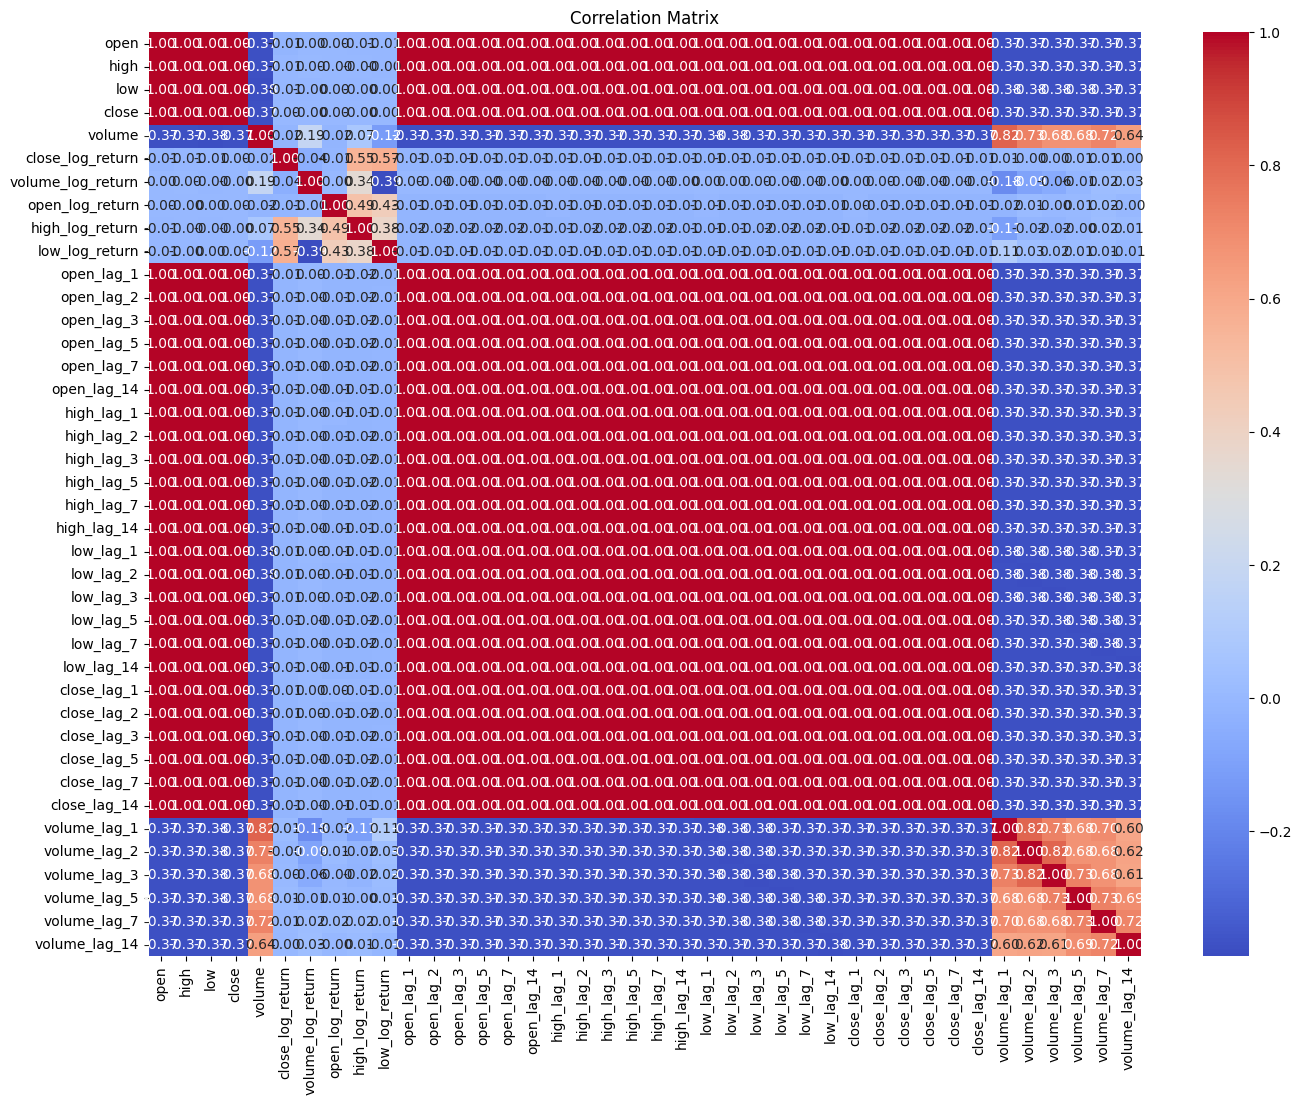

In [ ]:


plt.figure(figsize=(16,12))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")
plt.show()

### VIP

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

features = [
    'close_log_return',
    'volume_log_return',
    'open_log_return',
    'high_log_return',
    'low_log_return'
]

X = df[features].dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

             feature       VIF
0   close_log_return  3.056599
1  volume_log_return  1.753592
2    open_log_return  2.396015
3    high_log_return  3.165125
4     low_log_return  2.863581


### Lag Features

In [23]:
lags = [1, 2, 3, 5, 7, 14]

cols = ['open', 'high', 'low', 'close', 'volume']

for col in cols:
    for lag in lags:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)

df.head()

,datetime,open,high,low,close,volume,close_log_return,volume_log_return,open_log_return,high_log_return,...,close_lag_3,close_lag_5,close_lag_7,close_lag_14,volume_lag_1,volume_lag_2,volume_lag_3,volume_lag_5,volume_lag_7,volume_lag_14
0,2020-01-01 00:00:00,7195.24,7244.87,7175.46,7242.85,2050.024313,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-01 03:00:00,7242.66,7245.00,7215.03,7224.21,1596.208041,-0.002577,-0.250221,0.006569,0.000018,...,NaN,NaN,NaN,NaN,2050.024313,NaN,NaN,NaN,NaN,NaN
2,2020-01-01 06:00:00,7224.24,7236.27,7180.00,7200.64,2164.357851,-0.003268,0.304493,-0.002547,-0.001206,...,NaN,NaN,NaN,NaN,1596.208041,2050.024313,NaN,NaN,NaN,NaN
3,2020-01-01 09:00:00,7200.29,7237.73,7185.20,7197.20,2251.108387,-0.000478,0.039299,-0.003321,0.000202,...,7242.85,NaN,NaN,NaN,2164.357851,1596.208041,2050.024313,NaN,NaN,NaN
4,2020-01-01 12:00:00,7197.20,7234.97,7196.15,7221.43,2098.648667,0.003361,-0.070129,-0.000429,-0.000381,...,7224.21,NaN,NaN,NaN,2251.108387,2164.357851,1596.208041,NaN,NaN,NaN


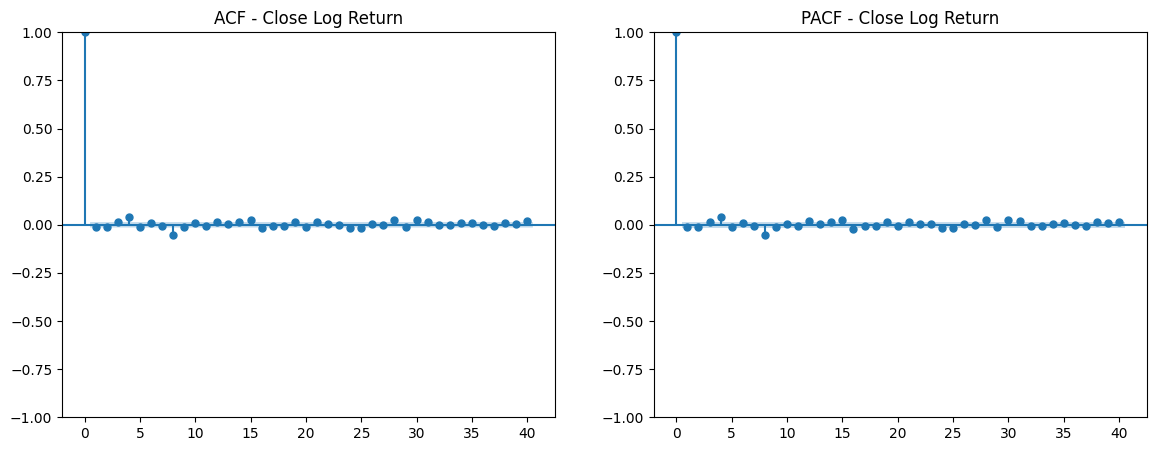

In [24]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

series = df['close_log_return'].dropna()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(series, lags=40, ax=ax[0])
plot_pacf(series, lags=40, ax=ax[1])

ax[0].set_title("ACF - Close Log Return")
ax[1].set_title("PACF - Close Log Return")

plt.show()

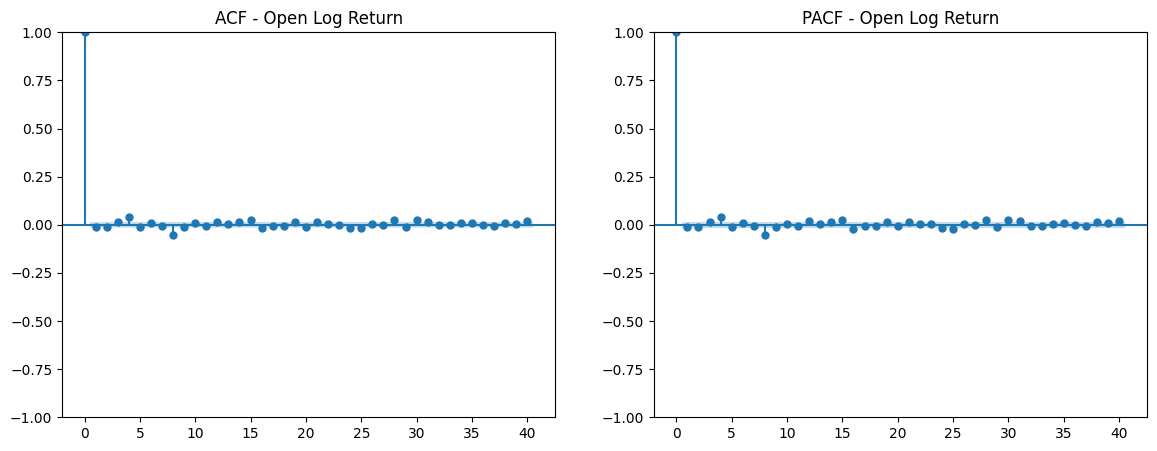

In [33]:
series = df['open_log_return'].dropna()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(series, lags=40, ax=ax[0])
plot_pacf(series, lags=40, ax=ax[1])

ax[0].set_title("ACF - Open Log Return")
ax[1].set_title("PACF - Open Log Return")

plt.show()

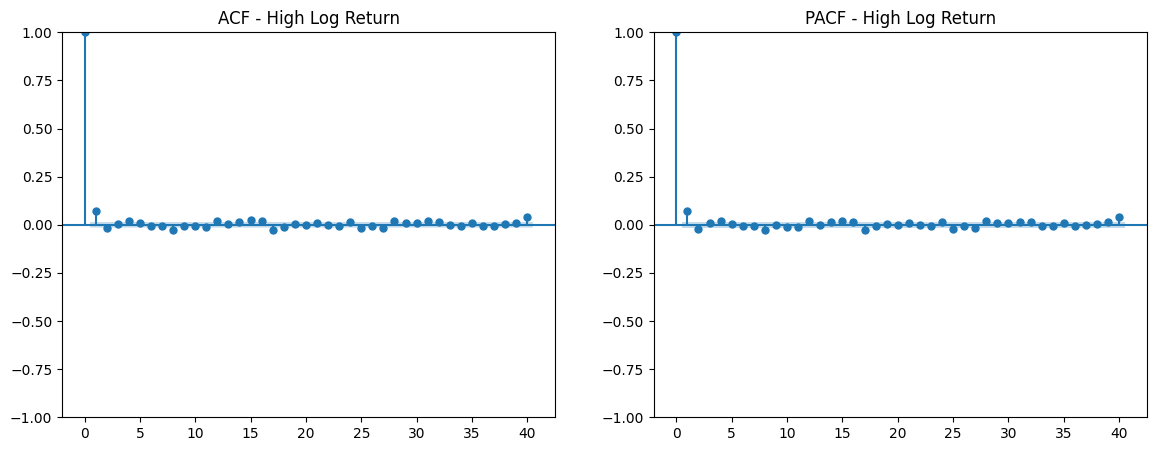

In [34]:
series = df['high_log_return'].dropna()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(series, lags=40, ax=ax[0])
plot_pacf(series, lags=40, ax=ax[1])

ax[0].set_title("ACF - High Log Return")
ax[1].set_title("PACF - High Log Return")

plt.show()

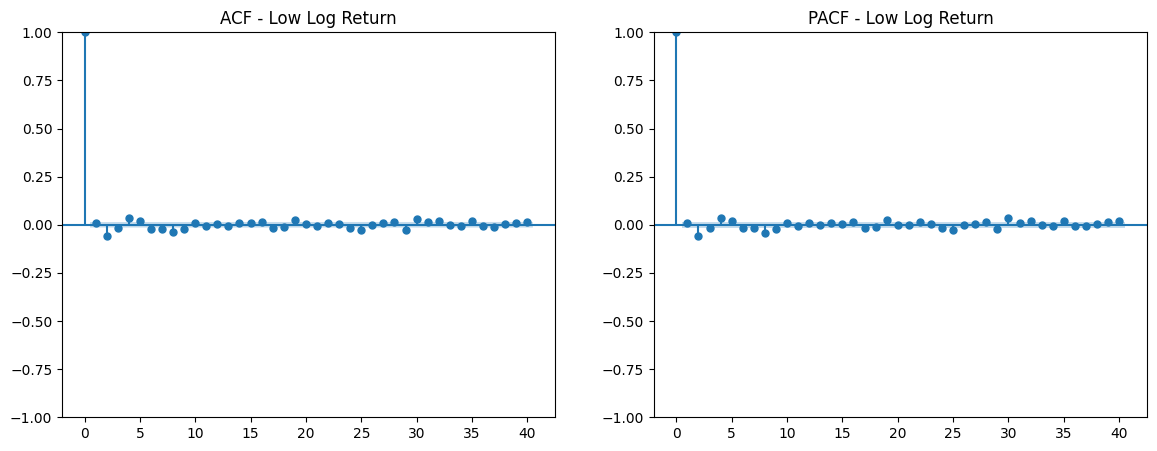

In [35]:
series = df['low_log_return'].dropna()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(series, lags=40, ax=ax[0])
plot_pacf(series, lags=40, ax=ax[1])

ax[0].set_title("ACF - Low Log Return")
ax[1].set_title("PACF - Low Log Return")

plt.show()

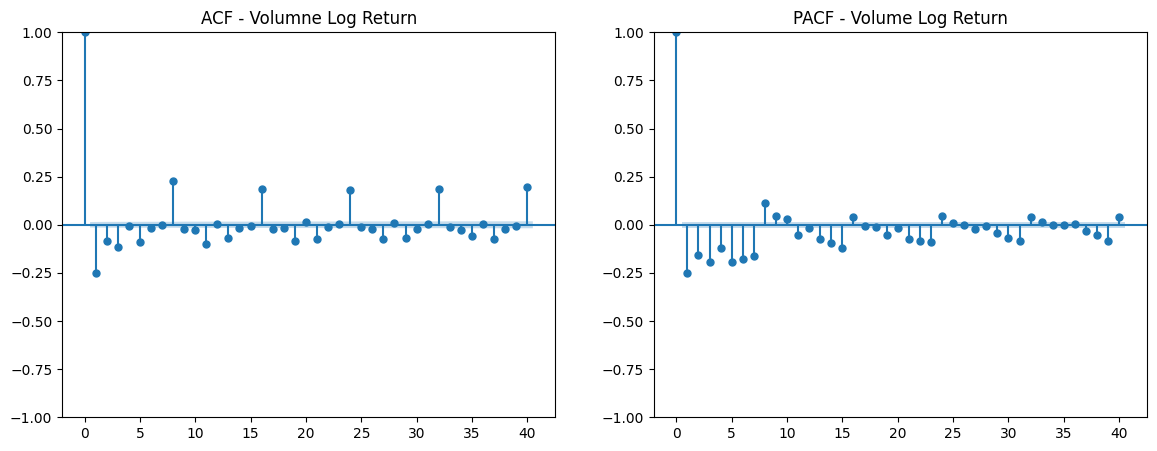

In [36]:
series = df['volume_log_return'].dropna()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(series, lags=40, ax=ax[0])
plot_pacf(series, lags=40, ax=ax[1])

ax[0].set_title("ACF - Volumne Log Return")
ax[1].set_title("PACF - Volume Log Return")

plt.show()

### Rolling Mean Window